# Step 4. Black-Litterman + 모멘텀 전략

| 항목 | 내용 |
|------|------|
| **참조 논문** | Lee & Bae (2024), 블랙리터만과 모멘텀을 결합한 적극적 자산배분 전략 연구, KCI |
| **Q (뷰 벡터)** | 6/9/12개월 연환산 모멘텀 수익률 평균 (논문 동일 방식) |
| **Ω (불확실성)** | 모멘텀 z-score 기반 Idzorek(2004) 방법 ← 논문의 %pos/%neg 대비 방향+크기 모두 반영 |
| **Prior π** | 등가중 시장 포트폴리오 기반 균형 수익률 (λΣw) |
| **백테스트** | 월 리밸런싱 walk-forward (2016-01 ~ 2025-12) |
| **리스크 프로파일** | 공격형(γ=2) / 중립형(γ=5) / 보수형(γ=8) |

## Omega 설계 근거

Lee & Bae(2024)는 과거 252일간 상승일 비율(%pos)로 신뢰도를 계산했으나,  
이 방법은 **방향성만** 반영하고 **신호 크기**를 무시한다는 한계가 있음.

본 구현에서는 **모멘텀 횡단면 z-score**를 신뢰도 기반으로 사용:
- 같은 날짜 내 30개 자산의 모멘텀 값을 z-score 표준화
- |z| 가 클수록 → 상대적으로 강한 신호 → 신뢰도 높음 → Ω 작음
- sigmoid 변환으로 신뢰도 [0.1, 0.9] 범위 제한
- Idzorek(2004): Ω_i = [(1-c_i)/c_i] × τ × Σ_ii

In [15]:
# ============================================================
# 라이브러리 임포트 + 데이터 로드
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os
from pathlib import Path
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'  # macOS
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA = Path('data')
IMG  = Path('images')
IMG.mkdir(exist_ok=True)

# ── 데이터 로드 ──
prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
prices = prices.sort_index()

ANALYSIS_START = '2016-01-01'

# ── 자산 그룹 정의 (Step1과 동일) ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
TICKERS    = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS
N = len(TICKERS)

# 결측 있는 XLRE 처리 — 분석 기간 이후는 완전 데이터
prices = prices[TICKERS]
prices = prices.ffill()

# 로그 수익률
log_ret = np.log(prices / prices.shift(1))

print(f'전체 가격 데이터: {prices.shape}')
print(f'자산 수: {N}개 — {TICKERS[:5]}...{TICKERS[-3:]}')
print(f'기간: {prices.index[0].date()} ~ {prices.index[-1].date()}')

전체 가격 데이터: (3017, 30)
자산 수: 30개 — ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']...['JNJ', 'PG', 'XOM']
기간: 2014-01-02 ~ 2025-12-30


---
## 4-1. 핵심 함수 정의

### Black-Litterman 수식

$$\mu_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1} \left[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\right]$$

$$\Sigma_{BL} = \Sigma + \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}$$

| 변수 | 의미 | 본 구현 |
|------|------|---------|
| **π** | Prior 균형 수익률 | λΣw (등가중, λ=2.5) |
| **Q** | 모멘텀 뷰 벡터 | 6/9/12개월 평균 연환산 수익률 |
| **P** | 뷰 선택 행렬 | 절대적 뷰 → Identity |
| **Ω** | 뷰 불확실성 | Idzorek + z-score 신뢰도 |
| **τ** | Prior 불확실성 척도 | 1/252 |
| **Σ** | 공분산 행렬 | Ledoit-Wolf (252일 롤링) |

In [16]:
# ============================================================
# BL 핵심 함수들
# ============================================================

def compute_prior(cov: np.ndarray, w_mkt: np.ndarray, lam: float = 2.5) -> np.ndarray:
    """
    아무 정보가 없을 때 시장이 기대하는 수익률 계산

    Prior 균형 수익률 π = λ × Σ × w_mkt : 시장 비중이 이미 최적화된 결과라면 그 때의 기대 수익률은 얼마인지 역으로 계산
    
    w_mkt: 시장 포트폴리오 비중 (등가중 1/N 사용)
    lam: 시장 위험회피계수 (S&P 500 Sharpe ÷ vol ≈ 2.5)
    """
    return lam * cov @ w_mkt


def compute_momentum_Q(
    prices_window: pd.DataFrame,
    windows: list = [126, 189, 252]  # 6m, 9m, 12m in trading days
) -> np.ndarray:
    """
    Lee & Bae (2024) 방식: 6/9/12개월 연환산 모멘텀 수익률 평균
    
    annualized log return = log(P_t / P_{t-w}) / w * 252
    Q = mean([ret_6m, ret_9m, ret_12m])
    """
    if len(prices_window) < max(windows) + 5:
        # 데이터 부족시 0 반환
        return np.zeros(prices_window.shape[1])
    
    p = prices_window.values  # (T, N)
    q_list = []
    for w in windows:
        if len(p) > w:
            # 연환산 로그 수익률
            ret_w = (np.log(p[-1]) - np.log(p[-w])) / w * 252
            q_list.append(ret_w)
    
    if not q_list:
        return np.zeros(prices_window.shape[1])
    return np.mean(q_list, axis=0)  # (N,)


def compute_omega_idzorek(
    Q: np.ndarray,
    cov: np.ndarray,
    tau: float = 1/252,
    c_min: float = 0.10,
    c_max: float = 0.90
) -> np.ndarray:
    """
    Idzorek(2004) 방법 + 모멘텀 z-score 기반 신뢰도
    
    개선 이유:
      Lee & Bae(2024)의 %pos/%neg는 방향성만 반영.
      횡단면 z-score는 방향 + 상대적 신호 크기를 동시에 반영.
    
    신뢰도 c_i:
      - Q를 횡단면 z-score 변환 → |z_i| 큰 자산 = 강한 신호
      - sigmoid 변환으로 [c_min, c_max] 범위로 제한
    
    Idzorek 공식:
      Ω_i = [(1 - c_i) / c_i] × τ × Σ_ii
    """
    # 횡단면 z-score
    q_std = Q.std() + 1e-10
    q_mean = Q.mean()
    z = (Q - q_mean) / q_std  # (N,)
    
    # sigmoid 변환: sigmoid(|z|) → [0.5, 1.0] → rescale to [c_min, c_max]
    sig = 1 / (1 + np.exp(-np.abs(z)))  # (N,) in [0.5, 1.0]
    confidence = c_min + (c_max - c_min) * (sig - 0.5) / 0.5  # [c_min, c_max]
    
    # Idzorek Ω_i = [(1 - c_i) / c_i] × τ × Σ_ii
    diag_cov = np.diag(cov)  # (N,)
    omega_diag = ((1 - confidence) / confidence) * tau * diag_cov
    return np.diag(omega_diag)  # (N, N) 대각행렬


def black_litterman(
    pi: np.ndarray,
    cov: np.ndarray,
    Q: np.ndarray,
    omega: np.ndarray,
    tau: float = 1/252,
    P: np.ndarray = None
) -> tuple:
    """
    Black-Litterman 사후 기대수익률 + 사후 공분산
    
    절대적 뷰 (P = Identity):
      μ_BL = [(τΣ)^-1 + Ω^-1]^-1 × [(τΣ)^-1 × π + Ω^-1 × Q]
      Σ_BL = Σ + [(τΣ)^-1 + Ω^-1]^-1
    
    Returns:
        mu_bl: 사후 기대수익률 (N,)
        sigma_bl: 사후 공분산 (N, N)
    """
    N = len(pi)
    if P is None:
        P = np.eye(N)  # 절대적 뷰
    
    tau_cov = tau * cov
    tau_cov_inv = np.linalg.inv(tau_cov)
    omega_inv = np.linalg.inv(omega)
    
    # 사후 정밀도 행렬
    precision = tau_cov_inv + P.T @ omega_inv @ P
    precision_inv = np.linalg.inv(precision)
    
    # 사후 평균
    mu_bl = precision_inv @ (tau_cov_inv @ pi + P.T @ omega_inv @ Q)
    
    # 사후 공분산 (He & Litterman 1999)
    sigma_bl = cov + precision_inv
    
    return mu_bl, sigma_bl


def mvo_optimize(
    mu: np.ndarray,
    cov: np.ndarray,
    gamma: float,
    constraints: dict = None
) -> np.ndarray:
    """
    Mean-Variance 최적화: max w'μ - (γ/2) w'Σw
    
    gamma: 위험회피계수
    constraints: {'max_weight': 0.15, 'max_equity': 0.90, 'min_bond': 0.05}
    """
    N = len(mu)
    
    if constraints is None:
        constraints = {}
    
    max_w  = constraints.get('max_weight', 0.20)
    max_eq = constraints.get('max_equity', 1.0)
    min_bn = constraints.get('min_bond', 0.0)
    
    # 자산군 인덱스
    equity_idx = [TICKERS.index(t) for t in INDEX_ETF + SECTOR_ETF + STOCKS if t in TICKERS]
    bond_idx   = [TICKERS.index(t) for t in BOND_ETF if t in TICKERS]
    
    def neg_utility(w):
        return -(w @ mu - (gamma / 2) * w @ cov @ w)
    
    constraints_list = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
    ]
    if equity_idx:
        constraints_list.append(
            {'type': 'ineq', 'fun': lambda w: max_eq - np.sum(w[equity_idx])}
        )
    if bond_idx:
        constraints_list.append(
            {'type': 'ineq', 'fun': lambda w: np.sum(w[bond_idx]) - min_bn}
        )
    
    bounds = [(0.0, max_w)] * N
    w0 = np.ones(N) / N
    
    result = minimize(
        neg_utility, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_list,
        options={'maxiter': 500, 'ftol': 1e-9}
    )
    
    if result.success:
        w = result.x
        w = np.clip(w, 0, None)
        w /= w.sum()
        return w
    else:
        # 최적화 실패 시 등가중 반환
        return np.ones(N) / N


print('BL 핵심 함수 정의 완료.')
print('  - compute_prior(): π = λΣw')
print('  - compute_momentum_Q(): 6/9/12개월 모멘텀 평균')
print('  - compute_omega_idzorek(): z-score 기반 Idzorek Ω')
print('  - black_litterman(): BL 사후 μ, Σ')
print('  - mvo_optimize(): MVO (γ 기반 리스크 프로파일)')

BL 핵심 함수 정의 완료.
  - compute_prior(): π = λΣw
  - compute_momentum_Q(): 6/9/12개월 모멘텀 평균
  - compute_omega_idzorek(): z-score 기반 Idzorek Ω
  - black_litterman(): BL 사후 μ, Σ
  - mvo_optimize(): MVO (γ 기반 리스크 프로파일)


---
## 4-2. 리스크 프로파일 정의

| 프로파일 | γ | 최대 주식 비중 | 최소 채권 비중 | 개별 종목 상한 |
|----------|---|--------------|--------------|---------------|
| 공격형 (Aggressive) | 2 | 90% | 5% | 20% |
| 중립형 (Neutral) | 5 | 70% | 15% | 15% |
| 보수형 (Conservative) | 8 | 50% | 30% | 10% |

In [17]:
# ============================================================
# 리스크 프로파일 정의
# ============================================================
PROFILES = {
    'Aggressive': {
        'gamma': 2,
        'max_equity': 0.90,
        'min_bond':   0.05,
        'max_weight': 0.20,
        'color': '#e74c3c'
    },
    'Neutral': {
        'gamma': 5,
        'max_equity': 0.70,
        'min_bond':   0.15,
        'max_weight': 0.15,
        'color': '#2ecc71'
    },
    'Conservative': {
        'gamma': 8,
        'max_equity': 0.50,
        'min_bond':   0.30,
        'max_weight': 0.10,
        'color': '#3498db'
    }
}

print('리스크 프로파일:')
for name, p in PROFILES.items():
    print(f'  {name:15s} γ={p["gamma"]}, 주식≤{p["max_equity"]*100:.0f}%, 채권≥{p["min_bond"]*100:.0f}%, 종목상한={p["max_weight"]*100:.0f}%')

리스크 프로파일:
  Aggressive      γ=2, 주식≤90%, 채권≥5%, 종목상한=20%
  Neutral         γ=5, 주식≤70%, 채권≥15%, 종목상한=15%
  Conservative    γ=8, 주식≤50%, 채권≥30%, 종목상한=10%


---
## 4-3. 단일 기간 예시 (2024-12-31 기준)

워크포워드 전에 BL 결과가 직관적으로 맞는지 검증합니다.

In [18]:
# ============================================================
# 단일 기간 예시: 2024-12-31 기준
# ============================================================
TAU = 1 / 252
LAM = 2.5
COV_WINDOW = 252    # 공분산 추정 롤링 윈도우

end_date = '2024-12-31'
p_window = prices.loc[:end_date].tail(COV_WINDOW + 252 + 30)  # 여유있게

# 공분산 (Ledoit-Wolf, 연율화)
r_window = np.log(p_window / p_window.shift(1)).dropna().tail(COV_WINDOW)
lw = LedoitWolf().fit(r_window.values)
cov = lw.covariance_ * 252

# Prior
w_mkt = np.ones(N) / N
pi = compute_prior(cov, w_mkt, lam=LAM)

# Q (모멘텀)
p_q = prices.loc[:end_date]
Q = compute_momentum_Q(p_q)

# Omega
omega = compute_omega_idzorek(Q, cov, tau=TAU)

# BL 사후
mu_bl, sigma_bl = black_litterman(pi, cov, Q, omega, tau=TAU)

# 결과 요약
result_df = pd.DataFrame({
    'Prior π (%)':   pi * 100,
    'Q 모멘텀 (%)':  Q * 100,
    'μ_BL (%)':      mu_bl * 100,
}, index=TICKERS)

print(f'=== 단일 기간 BL 결과 ({end_date}) ===')
print(result_df.sort_values('μ_BL (%)', ascending=False).round(2).to_string())
print(f'\nQ 평균: {Q.mean()*100:.2f}%   Prior 평균: {pi.mean()*100:.2f}%   μ_BL 평균: {mu_bl.mean()*100:.2f}%')

=== 단일 기간 BL 결과 (2024-12-31) ===
       Prior π (%)  Q 모멘텀 (%)  μ_BL (%)
AAPL          2.44      35.92     26.05
AMZN          3.71      27.87     24.95
JPM           2.37      31.05     23.14
GOOGL         3.25      21.09     22.68
XLY           3.20      30.35     22.67
XLK           3.42      13.05     18.46
IWM           3.54      13.81     17.97
QQQ           3.05      17.71     17.92
VOX           2.63      24.69     17.16
XLF           2.08      26.49     16.30
MSFT          2.76      -0.81     13.96
SPY           2.47      17.88     13.94
XLI           2.33      14.37     11.50
XLU           1.35      21.95      9.79
XLRE          2.06      10.53      9.18
GLD           1.34      20.71      6.63
EFA           2.09      -1.78      5.52
EEM           2.16       2.65      5.05
XLP           0.98       9.46      4.37
XLB           2.23      -5.81      4.14
XLV           1.37      -3.44      1.81
SHY           0.10       4.68      1.41
PG            0.38      11.11      1.23
AGG    

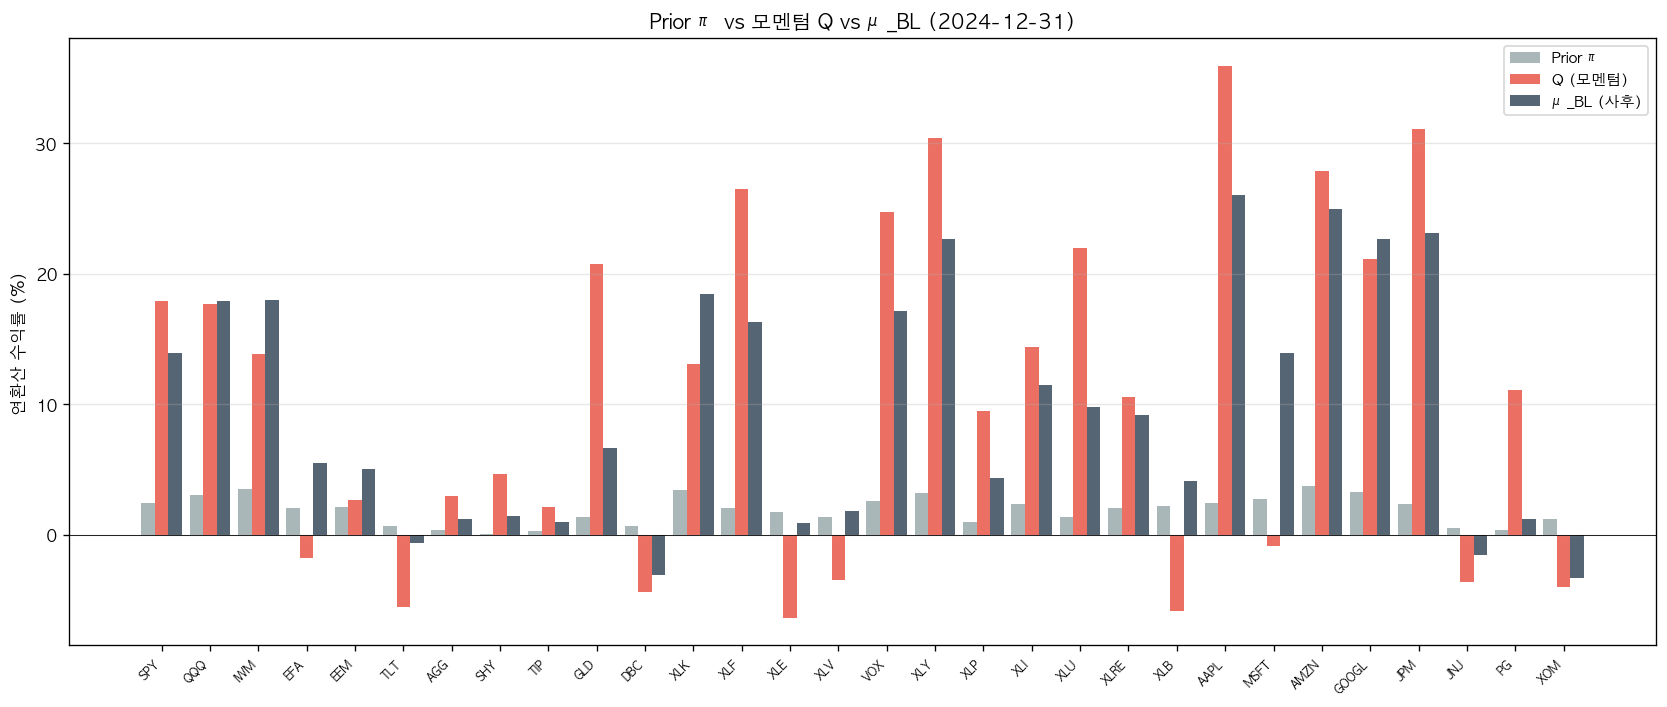

저장: images/step4_01_bl_single_period.png


In [19]:
# ── 시각화: Prior vs Q vs μ_BL 비교 ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(N)
w = 0.28

ax.bar(x - w, pi * 100, width=w, label='Prior π', color='#95a5a6', alpha=0.8)
ax.bar(x,     Q * 100,  width=w, label='Q (모멘텀)', color='#e74c3c', alpha=0.8)
ax.bar(x + w, mu_bl * 100, width=w, label='μ_BL (사후)', color='#2c3e50', alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('연환산 수익률 (%)')
ax.set_title(f'Prior π vs 모멘텀 Q vs μ_BL ({end_date})', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(IMG / 'step4_01_bl_single_period.png', bbox_inches='tight')
plt.show()
print('저장: images/step4_01_bl_single_period.png')

---
## 4-4. Walk-Forward 백테스트

### 설계

| 파라미터 | 값 | 근거 |
|---------|-----|------|
| 공분산 윈도우 | 252 거래일 | 1년 롤링 |
| 모멘텀 윈도우 | 최대 252일 (12개월) | Lee & Bae (2024) |
| 리밸런싱 | 21 거래일 (월 1회) | 논문 동일 |
| 분석 기간 | 2016-01 ~ 2025-12 | 코로나·금리인상 포함 |
| 워밍업 | 2014-01 ~ 2015-12 | 공분산 추정 안정화 |

### 벤치마크
- **SPY Buy & Hold**: 단순 SPY 보유
- **Equal Weight**: 30개 자산 등가중, 월 리밸런싱

In [20]:
# ============================================================
# Walk-Forward 백테스트
# ============================================================

REBAL_DAYS = 21    # 월 리밸런싱
COV_WIN    = 252   # 공분산 추정 윈도우
MOM_WIN    = 252   # 모멘텀 최대 윈도우 (12개월)
TAU        = 1 / 252
LAM        = 2.5

# 분석 기간 실거래일
analysis_days = prices.loc[ANALYSIS_START:].index
print(f'분석 기간: {analysis_days[0].date()} ~ {analysis_days[-1].date()} ({len(analysis_days)}일)')
print(f'리밸런싱 횟수: ~{len(analysis_days) // REBAL_DAYS}회')

# ── 백테스트 실행 ──────────────────────────────────────────
# 결과 저장: 각 프로파일의 일별 포트폴리오 가치
portfolio_values = {name: [1.0] for name in PROFILES}
portfolio_dates  = [analysis_days[0]]
portfolio_weights = {name: [] for name in PROFILES}
rebal_dates = []

# 현재 비중 초기화 (등가중)
current_weights = {name: np.ones(N) / N for name in PROFILES}

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]
    
    # 일별 수익률로 포트폴리오 가치 업데이트
    daily_ret = prices.loc[date] / prices.loc[prev_date] - 1
    daily_ret = daily_ret.fillna(0).values  # (N,)
    
    for name in PROFILES:
        port_ret = current_weights[name] @ daily_ret
        new_val  = portfolio_values[name][-1] * (1 + port_ret)
        portfolio_values[name].append(new_val)
    
    portfolio_dates.append(date)
    
    # 리밸런싱 여부 확인
    if i % REBAL_DAYS != 0:
        continue
    
    rebal_dates.append(date)
    
    # 현재 날짜까지 데이터로 BL 계산
    p_avail = prices.loc[:date]
    
    # 공분산 추정 (Ledoit-Wolf)
    r_avail = np.log(p_avail / p_avail.shift(1)).dropna().tail(COV_WIN)
    if len(r_avail) < 60:  # 최소 데이터 부족
        continue
    
    try:
        lw_model = LedoitWolf().fit(r_avail.values)
        cov = lw_model.covariance_ * 252
    except Exception:
        continue
    
    # Prior
    w_mkt = np.ones(N) / N
    pi_vec = compute_prior(cov, w_mkt, lam=LAM)
    
    # Q (모멘텀)
    Q_vec = compute_momentum_Q(p_avail)
    
    # Omega
    omega = compute_omega_idzorek(Q_vec, cov, tau=TAU)
    
    # BL 사후
    try:
        mu_bl, sigma_bl = black_litterman(pi_vec, cov, Q_vec, omega, tau=TAU)
    except np.linalg.LinAlgError:
        continue
    
    # 각 프로파일별 MVO
    for name, profile in PROFILES.items():
        constraints = {
            'max_equity': profile['max_equity'],
            'min_bond':   profile['min_bond'],
            'max_weight': profile['max_weight']
        }
        w_opt = mvo_optimize(mu_bl, sigma_bl, profile['gamma'], constraints)
        current_weights[name] = w_opt
        portfolio_weights[name].append((date, w_opt.copy()))

print(f'\n백테스트 완료!')
print(f'리밸런싱 실행 횟수: {len(rebal_dates)}회')
for name in PROFILES:
    final = portfolio_values[name][-1]
    print(f'  {name:15s}: 최종 자산가치 = {final:.4f} (총 수익률 {(final-1)*100:.1f}%)')

분석 기간: 2016-01-04 ~ 2025-12-30 (2513일)
리밸런싱 횟수: ~119회

백테스트 완료!
리밸런싱 실행 횟수: 119회
  Aggressive     : 최종 자산가치 = 4.0084 (총 수익률 300.8%)
  Neutral        : 최종 자산가치 = 3.1043 (총 수익률 210.4%)
  Conservative   : 최종 자산가치 = 2.7948 (총 수익률 179.5%)


In [21]:
# ── 벤치마크 계산 ──────────────────────────────────────────
# SPY Buy & Hold
spy_prices = prices.loc[analysis_days, 'SPY']
spy_bh = (spy_prices / spy_prices.iloc[0]).values

# Equal Weight (월 리밸런싱)
ew_values = [1.0]
ew_weights = np.ones(N) / N

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]
    daily_ret = prices.loc[date] / prices.loc[prev_date] - 1
    daily_ret = daily_ret.fillna(0).values
    ew_values.append(ew_values[-1] * (1 + ew_weights @ daily_ret))
    if i % REBAL_DAYS == 0:
        ew_weights = np.ones(N) / N  # 등가중 리셋

# DataFrame으로 정리
perf_df = pd.DataFrame(index=pd.DatetimeIndex(portfolio_dates))
for name in PROFILES:
    perf_df[name] = portfolio_values[name]
perf_df['Equal Weight'] = ew_values
perf_df['SPY B&H'] = spy_bh

print(f'성능 DataFrame: {perf_df.shape}')
print(perf_df.tail(3))

성능 DataFrame: (2513, 5)
            Aggressive   Neutral  Conservative  Equal Weight   SPY B&H
2025-12-26    4.050880  3.129393      2.810545      3.518965  4.051776
2025-12-29    4.009902  3.104967      2.793616      3.508642  4.037337
2025-12-30    4.008387  3.104348      2.794781      3.508435  4.032407


---
## 4-5. 성능 지표 측정

In [22]:
# ============================================================
# 성능 지표 계산 함수
# ============================================================

def compute_metrics(values: np.ndarray, name: str = '') -> dict:
    """
    포트폴리오 성능 지표 계산
    
    Returns:
        Sharpe, Sortino, MDD, 연환산 수익률, 연환산 변동성, Calmar, 총 수익률
    """
    v = np.array(values)
    rets = np.diff(v) / v[:-1]  # 일별 수익률
    
    # 연환산 수익률
    n_years = len(v) / 252
    total_ret = v[-1] / v[0] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1
    
    # 연환산 변동성
    ann_vol = rets.std() * np.sqrt(252)
    
    # Sharpe (무위험 수익률 0% 가정)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    # Sortino (하방 변동성만)
    downside = rets[rets < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else 1e-10
    sortino = ann_ret / down_vol
    
    # MDD
    peak = np.maximum.accumulate(v)
    drawdown = (v - peak) / peak
    mdd = drawdown.min()
    
    # Calmar
    calmar = ann_ret / abs(mdd) if mdd < 0 else 0
    
    return {
        '전략':           name,
        '총 수익률 (%)':   round(total_ret * 100, 2),
        '연환산 수익률 (%)': round(ann_ret * 100, 2),
        '연환산 변동성 (%)': round(ann_vol * 100, 2),
        'Sharpe':         round(sharpe, 3),
        'Sortino':        round(sortino, 3),
        'MDD (%)':        round(mdd * 100, 2),
        'Calmar':         round(calmar, 3),
    }


# ── 전략별 성능 계산 ──────────────────────────────────────
metrics_list = []

for name in PROFILES:
    m = compute_metrics(perf_df[name].values, name=f'BL-{name}')
    metrics_list.append(m)

metrics_list.append(compute_metrics(perf_df['Equal Weight'].values, name='Equal Weight'))
metrics_list.append(compute_metrics(perf_df['SPY B&H'].values, name='SPY Buy & Hold'))

metrics_df = pd.DataFrame(metrics_list).set_index('전략')

print('=' * 90)
print('성능 지표 (2016-01 ~ 2025-12)')
print('=' * 90)
print(metrics_df.to_string())

# CSV 저장
metrics_df.to_csv(DATA / 'bl_performance_metrics.csv')
print('\n→ data/bl_performance_metrics.csv 저장')

성능 지표 (2016-01 ~ 2025-12)
                 총 수익률 (%)  연환산 수익률 (%)  연환산 변동성 (%)  Sharpe  Sortino  MDD (%)  Calmar
전략                                                                                    
BL-Aggressive       300.84        14.94        17.83   0.838    1.074   -24.14   0.619
BL-Neutral          210.43        12.03        14.70   0.818    1.026   -23.58   0.510
BL-Conservative     179.48        10.86        11.19   0.970    1.226   -17.06   0.636
Equal Weight        250.84        13.41        14.03   0.956    1.142   -28.09   0.477
SPY Buy & Hold      303.24        15.01        18.01   0.833    1.001   -33.72   0.445

→ data/bl_performance_metrics.csv 저장


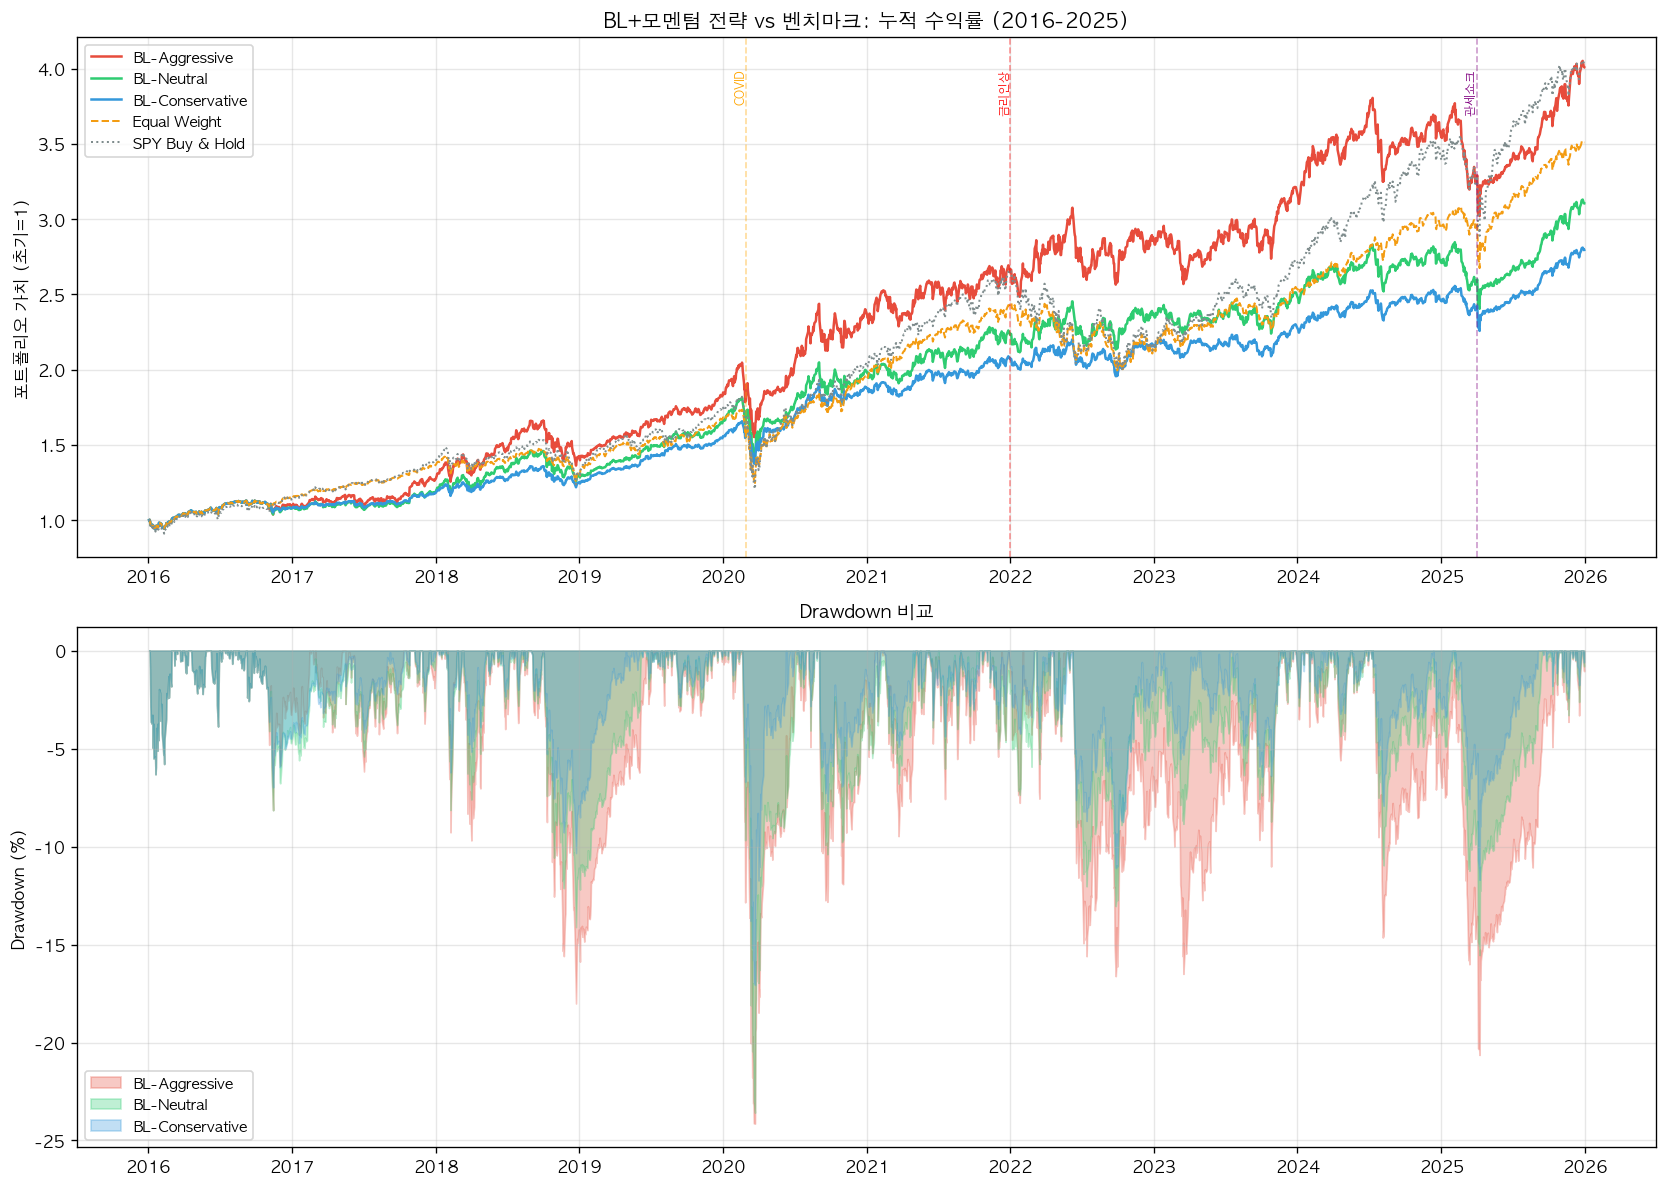

저장: images/step4_02_bl_cumulative.png


In [23]:
# ── 시각화 1: 누적 수익률 곡선 ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# (상단) 누적 수익률
ax = axes[0]
for name, profile in PROFILES.items():
    ax.plot(perf_df.index, perf_df[name], label=f'BL-{name}',
            color=profile['color'], linewidth=1.5)
ax.plot(perf_df.index, perf_df['Equal Weight'], label='Equal Weight',
        color='#f39c12', linewidth=1.2, linestyle='--')
ax.plot(perf_df.index, perf_df['SPY B&H'], label='SPY Buy & Hold',
        color='#7f8c8d', linewidth=1.2, linestyle=':')

# 주요 이벤트 표시
events = {
    '2020-03': ('COVID', 'orange'),
    '2022-01': ('금리인상', 'red'),
    '2025-04': ('관세쇼크', 'purple'),
}
for date_str, (label, color) in events.items():
    try:
        ax.axvline(pd.Timestamp(date_str), color=color, alpha=0.4,
                   linewidth=1.0, linestyle='--')
        ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * 0.95, label,
                rotation=90, va='top', ha='right', fontsize=7, color=color)
    except Exception:
        pass

ax.set_ylabel('포트폴리오 가치 (초기=1)')
ax.set_title('BL+모멘텀 전략 vs 벤치마크: 누적 수익률 (2016-2025)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (하단) Drawdown
ax2 = axes[1]
for name, profile in PROFILES.items():
    v = perf_df[name].values
    peak = np.maximum.accumulate(v)
    dd = (v - peak) / peak * 100
    ax2.fill_between(perf_df.index, dd, 0, alpha=0.3, color=profile['color'],
                     label=f'BL-{name}')
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown 비교', fontsize=11, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
fig.savefig(IMG / 'step4_02_bl_cumulative.png', bbox_inches='tight')
plt.show()
print('저장: images/step4_02_bl_cumulative.png')

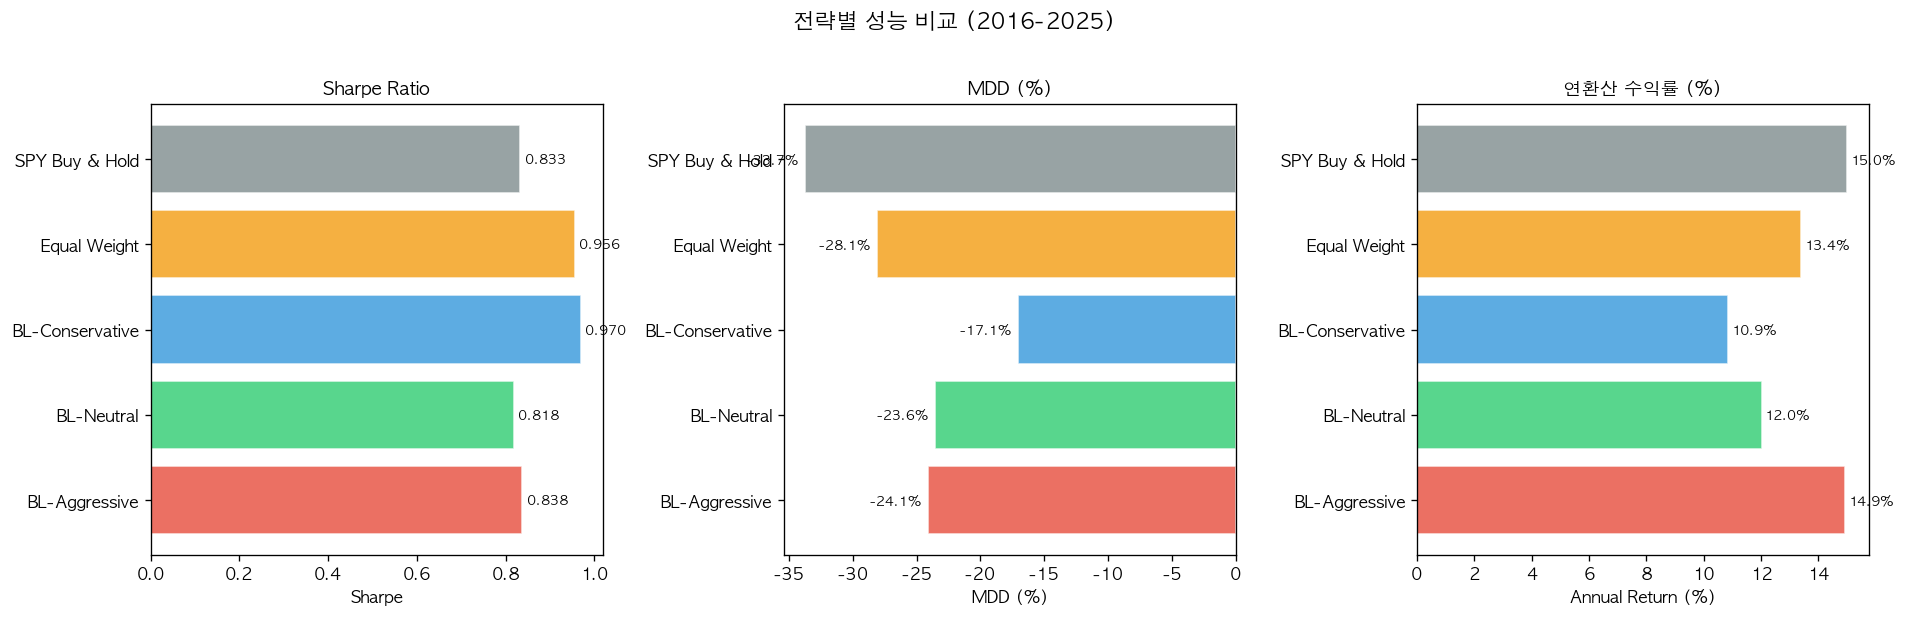

저장: images/step4_03_bl_metrics.png


In [24]:
# ── 시각화 2: 성능 지표 요약 테이블 시각화 ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies = metrics_df.index.tolist()
colors_bar = [
    PROFILES['Aggressive']['color'],
    PROFILES['Neutral']['color'],
    PROFILES['Conservative']['color'],
    '#f39c12',
    '#7f8c8d'
]

# Sharpe
ax = axes[0]
sharpes = metrics_df['Sharpe'].values
bars = ax.barh(strategies, sharpes, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Sharpe Ratio', fontsize=11, fontweight='bold')
ax.set_xlabel('Sharpe')
for bar, val in zip(bars, sharpes):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# MDD
ax = axes[1]
mdds = metrics_df['MDD (%)'].values
bars = ax.barh(strategies, mdds, color=colors_bar, alpha=0.8, edgecolor='white')
ax.set_title('MDD (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('MDD (%)')
for bar, val in zip(bars, mdds):
    ax.text(val - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right', fontsize=8)

# 연환산 수익률
ax = axes[2]
ann_rets = metrics_df['연환산 수익률 (%)'].values
bars = ax.barh(strategies, ann_rets, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('연환산 수익률 (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Annual Return (%)')
for bar, val in zip(bars, ann_rets):
    x_pos = val + 0.1 if val >= 0 else val - 0.1
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('전략별 성능 비교 (2016-2025)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(IMG / 'step4_03_bl_metrics.png', bbox_inches='tight')
plt.show()
print('저장: images/step4_03_bl_metrics.png')

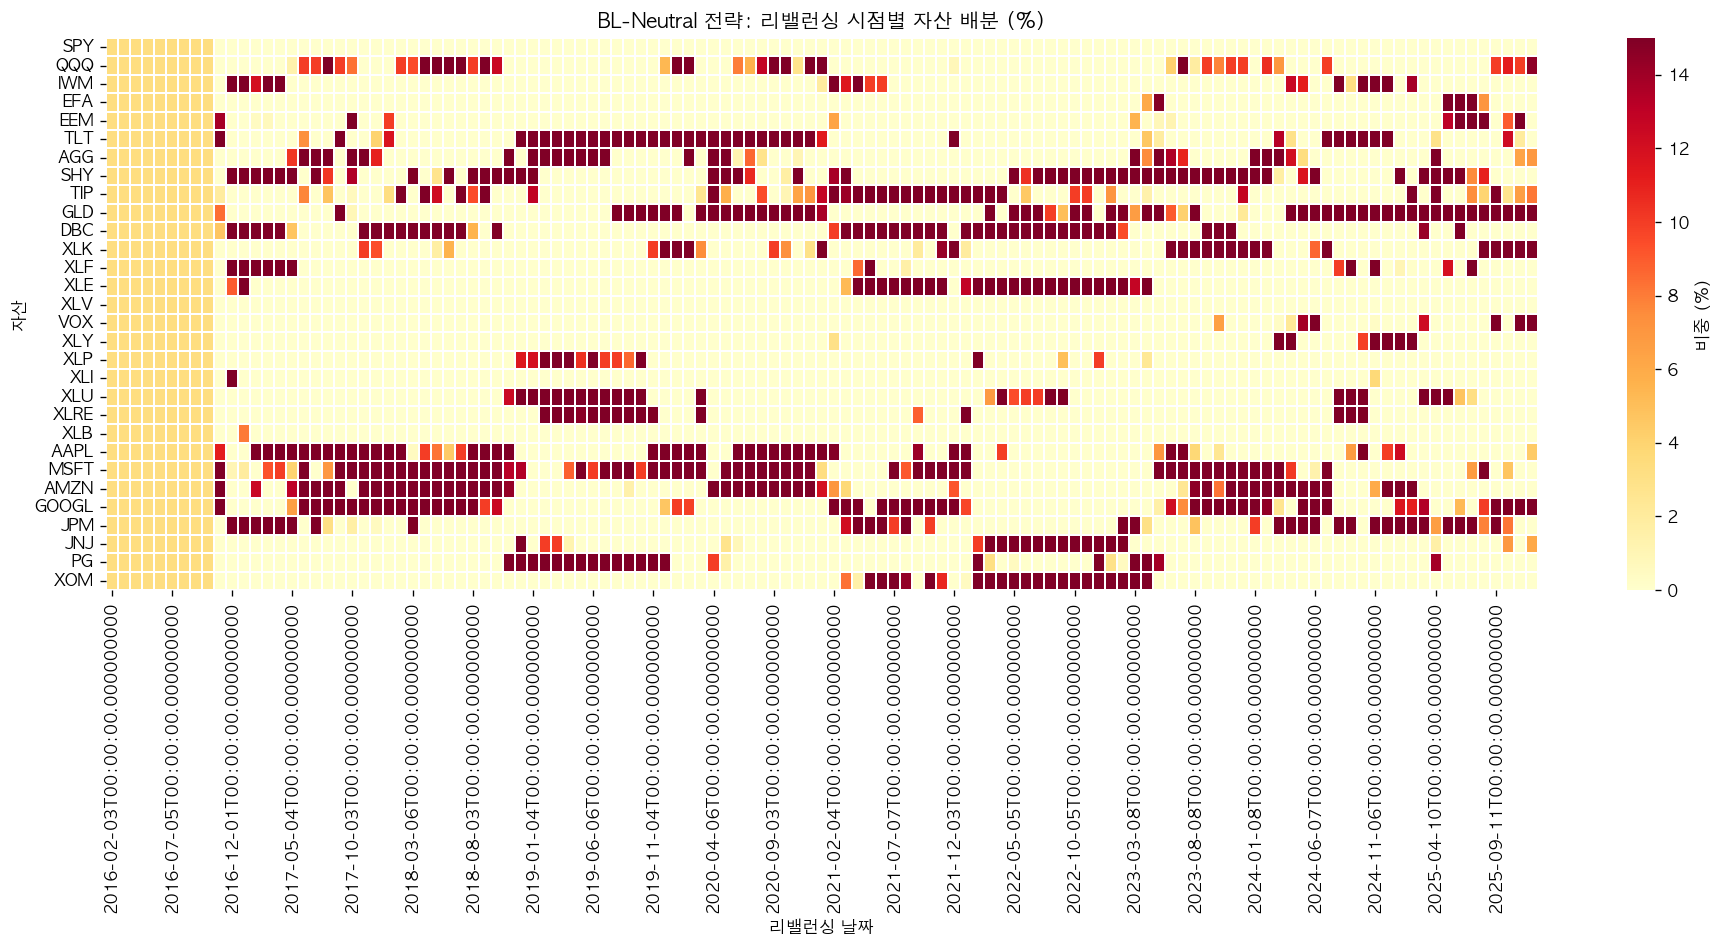

저장: images/step4_04_bl_weights_heatmap.png


In [25]:
# ── 시각화 3: 리밸런싱 시점 자산 배분 히트맵 (Neutral) ──────────
if portfolio_weights['Neutral']:
    # Neutral 프로파일의 리밸런싱 시점 비중 추출
    rebal_records = portfolio_weights['Neutral']
    dates_rebal = [r[0] for r in rebal_records]
    weights_arr = np.array([r[1] for r in rebal_records])  # (n_rebal, N)
    
    wt_df = pd.DataFrame(weights_arr, index=pd.DatetimeIndex(dates_rebal), columns=TICKERS)
    
    # 자산군 그룹 순서로 정렬
    wt_df = wt_df[TICKERS]  # 이미 TICKERS 순서
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    import seaborn as sns
    sns.heatmap(
        wt_df.T * 100,
        ax=ax,
        cmap='YlOrRd',
        xticklabels=max(1, len(wt_df) // 20),
        yticklabels=True,
        cbar_kws={'label': '비중 (%)'},
        linewidths=0.1
    )
    ax.set_title('BL-Neutral 전략: 리밸런싱 시점별 자산 배분 (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('리밸런싱 날짜')
    ax.set_ylabel('자산')
    
    plt.tight_layout()
    fig.savefig(IMG / 'step4_04_bl_weights_heatmap.png', bbox_inches='tight')
    plt.show()
    print('저장: images/step4_04_bl_weights_heatmap.png')
else:
    print('리밸런싱 기록 없음')

---
## 4-6. 구간별 성능 분석 (상승장 vs 하락장)

2010-2019 상승장 편향 우려에 대응하여, 구간별 성능을 분리 측정합니다.

In [26]:
# ============================================================
# 구간별 성능 분석 (상승장 vs 하락장 / 이벤트별)
# ============================================================

SUB_PERIODS = {
    '전체 (2016-2025)':     ('2016-01-01', '2025-12-31'),
    '상승장 (2017-2019)':   ('2017-01-01', '2019-12-31'),
    '코로나 (2020)':        ('2020-01-01', '2020-12-31'),
    '회복장 (2021)':        ('2021-01-01', '2021-12-31'),
    '하락장 (2022)':        ('2022-01-01', '2022-12-31'),
    '반등 (2023-2024)':     ('2023-01-01', '2024-12-31'),
    '관세쇼크 (2025)':      ('2025-01-01', '2025-12-31'),
}

period_metrics = []

for period_name, (start, end) in SUB_PERIODS.items():
    sub = perf_df.loc[start:end]
    if len(sub) < 5:
        continue
    
    for col in ['BL-Aggressive', 'BL-Neutral', 'BL-Conservative', 'Equal Weight', 'SPY B&H']:
        col_key = col.replace('BL-', '')  # 위해 매핑
        if col in sub.columns:
            v = sub[col].values
            n_years = len(v) / 252
            total_ret = v[-1] / v[0] - 1
            ann_ret = (1 + total_ret) ** (1 / max(n_years, 0.1)) - 1
            rets = np.diff(v) / v[:-1]
            vol = rets.std() * np.sqrt(252)
            sharpe = ann_ret / vol if vol > 0 else 0
            peak = np.maximum.accumulate(v)
            mdd = ((v - peak) / peak).min()
            
            period_metrics.append({
                '기간':   period_name,
                '전략':   col,
                'Ann.Ret (%)': round(ann_ret * 100, 1),
                'Sharpe': round(sharpe, 2),
                'MDD (%)': round(mdd * 100, 1),
            })

period_df = pd.DataFrame(period_metrics)

# 피벗: 기간 × 전략 × Sharpe
sharpe_pivot = period_df.pivot(index='기간', columns='전략', values='Sharpe')
ret_pivot    = period_df.pivot(index='기간', columns='전략', values='Ann.Ret (%)')
mdd_pivot    = period_df.pivot(index='기간', columns='전략', values='MDD (%)')

# 기간 순서 유지
period_order = [k for k in SUB_PERIODS.keys() if k in sharpe_pivot.index]
sharpe_pivot = sharpe_pivot.loc[period_order]
ret_pivot    = ret_pivot.loc[period_order]
mdd_pivot    = mdd_pivot.loc[period_order]

print('=== 구간별 Sharpe Ratio ===')
print(sharpe_pivot.to_string())
print('\n=== 구간별 연환산 수익률 (%) ===')
print(ret_pivot.to_string())

# CSV 저장
period_df.to_csv(DATA / 'bl_period_metrics.csv', index=False)
print('\n→ data/bl_period_metrics.csv 저장')

=== 구간별 Sharpe Ratio ===
전략               Equal Weight  SPY B&H
기간                                    
전체 (2016-2025)           0.96     0.83
상승장 (2017-2019)          1.33     1.16
코로나 (2020)               0.61     0.51
회복장 (2021)               2.41     2.36
하락장 (2022)              -0.66    -0.77
반등 (2023-2024)           1.83     2.02
관세쇼크 (2025)              1.49     0.98

=== 구간별 연환산 수익률 (%) ===
전략               Equal Weight  SPY B&H
기간                                    
전체 (2016-2025)           13.4     15.0
상승장 (2017-2019)          13.3     14.8
코로나 (2020)               16.6     17.2
회복장 (2021)               24.6     30.5
하락장 (2022)              -12.4    -18.7
반등 (2023-2024)           17.7     25.9
관세쇼크 (2025)              19.6     19.1

→ data/bl_period_metrics.csv 저장


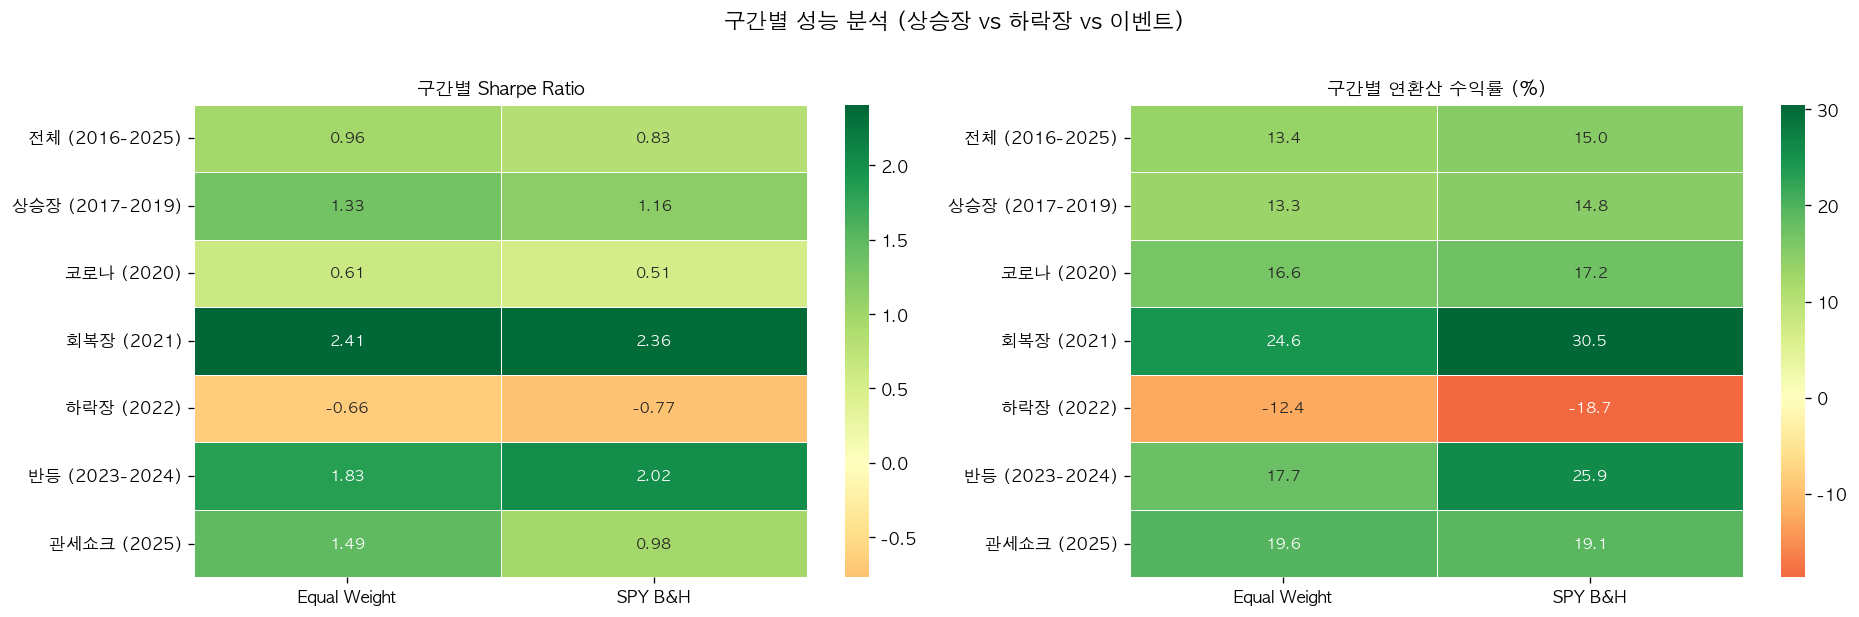

저장: images/step4_05_bl_period_heatmap.png


In [27]:
# ── 구간별 Sharpe 히트맵 ──────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sharpe 히트맵
ax = axes[0]
sns.heatmap(
    sharpe_pivot,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('구간별 Sharpe Ratio', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

# 연환산 수익률 히트맵
ax = axes[1]
sns.heatmap(
    ret_pivot,
    ax=ax,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('구간별 연환산 수익률 (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')

plt.suptitle('구간별 성능 분석 (상승장 vs 하락장 vs 이벤트)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(IMG / 'step4_05_bl_period_heatmap.png', bbox_inches='tight')
plt.show()
print('저장: images/step4_05_bl_period_heatmap.png')

In [28]:
# ── 최종 요약 ────────────────────────────────────────────────
print('=' * 70)
print('  Step 4. Black-Litterman + 모멘텀 전략 완료')
print('=' * 70)
print(f'  분석 기간    : {ANALYSIS_START} ~ 2025-12-31')
print(f'  자산 수      : {N}개')
print(f'  리밸런싱     : {REBAL_DAYS}일 (월 1회)')
print(f'  Q 방법       : 6/9/12개월 모멘텀 평균 (Lee & Bae 2024)')
print(f'  Ω 방법       : z-score 기반 Idzorek(2004)')
print()
print('  성능 요약 (전체 기간):')
print(metrics_df[['총 수익률 (%)', '연환산 수익률 (%)', 'Sharpe', 'MDD (%)']].to_string())
print()
print('  저장 파일:')
print('    - data/bl_performance_metrics.csv')
print('    - data/bl_period_metrics.csv')
print('    - images/step4_01_bl_single_period.png')
print('    - images/step4_02_bl_cumulative.png')
print('    - images/step4_03_bl_metrics.png')
print('    - images/step4_04_bl_weights_heatmap.png')
print('    - images/step4_05_bl_period_heatmap.png')
print('=' * 70)

  Step 4. Black-Litterman + 모멘텀 전략 완료
  분석 기간    : 2016-01-01 ~ 2025-12-31
  자산 수      : 30개
  리밸런싱     : 21일 (월 1회)
  Q 방법       : 6/9/12개월 모멘텀 평균 (Lee & Bae 2024)
  Ω 방법       : z-score 기반 Idzorek(2004)

  성능 요약 (전체 기간):
                 총 수익률 (%)  연환산 수익률 (%)  Sharpe  MDD (%)
전략                                                      
BL-Aggressive       300.84        14.94   0.838   -24.14
BL-Neutral          210.43        12.03   0.818   -23.58
BL-Conservative     179.48        10.86   0.970   -17.06
Equal Weight        250.84        13.41   0.956   -28.09
SPY Buy & Hold      303.24        15.01   0.833   -33.72

  저장 파일:
    - data/bl_performance_metrics.csv
    - data/bl_period_metrics.csv
    - images/step4_01_bl_single_period.png
    - images/step4_02_bl_cumulative.png
    - images/step4_03_bl_metrics.png
    - images/step4_04_bl_weights_heatmap.png
    - images/step4_05_bl_period_heatmap.png
